In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
# Load the medical appointment dataset
df = pd.read_csv("Medical_appointment_data.csv")

In [56]:
def clean_data(df):

    # Find text columns
    text_cols = df.select_dtypes(include='object').columns

    for col in text_cols:

        # Remove extra spaces from beginning and end
        df[col] = df[col].str.strip()

        # Convert text to lowercase
        df[col] = df[col].str.lower()

        # Remove special characters
        df[col] = df[col].str.replace(
            r'[^a-zA-Z0-9 ]',
            '',
            regex=True
        )

        # Replace spaces with underscore
        df[col] = df[col].str.replace(
            r'\s+',
            '_',
            regex=True
        )

    return df


# Call function
df = clean_data(df)

In [57]:
# Display the first 5 rows of the dataset
df.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,f,yes,intellectual,lake_marvinville,afternoon,9.0,1,0,...,1,norain,warm,20200101,0,0,0,0,0,0
1,NaN,7,m,no,intellectual,itapema,morning,11.0,1,0,...,1,norain,cold,20200101,0,0,0,0,0,0
2,speech_therapy,16,m,no,intellectual,itaja,afternoon,8.0,1,0,...,1,norain,warm,20200101,0,0,0,0,0,0
3,speech_therapy,14,m,yes,intellectual,sarahside,afternoon,9.0,1,0,...,1,moderate,mild,20200101,0,0,0,0,0,1
4,physiotherapy,8,m,no,motor,itaja,morning,NaN,0,0,...,1,norain,mild,20200101,0,0,0,0,0,0


In [58]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing[missing > 0].index,
    'Missing_Count': missing[missing > 0].values,
    'Data_Type': df[missing[missing > 0].index].dtypes.values
})

missing_df

,Column,Missing_Count,Data_Type
0,specialty,20127,object
1,disability,16601,object
2,place,11539,object
3,age,22960,float64
4,average_temp_day,2211,float64
5,average_rain_day,2245,float64
6,max_temp_day,2227,float64
7,max_rain_day,2263,float64


In [59]:
df['specialty'] = df['specialty'].fillna(df['specialty'].mode()[0])
df['disability'] = df['disability'].fillna(df['disability'].mode()[0])
df['place'] = df['place'].fillna(df['place'].mode()[0])

In [60]:
df['gender'].value_counts(dropna=False)

gender
m    82269
f    27077
i      247
Name: count, dtype: int64

In [61]:
# 1. 'i' ko missing value (NaN) bana do
df['gender'] = df['gender'].replace('i', pd.NA)

# 2. Missing gender ko mode se fill karo
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

# 3. f/m ko numeric mein convert karo
df['gender'] = df['gender'].map({
    'f': 0,
    'm': 1
})

# 4. Integer type
df['gender'] = df['gender'].astype(int)

In [62]:
df['gender'].value_counts(dropna=False)

gender
1    82516
0    27077
Name: count, dtype: int64

In [63]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing[missing > 0].index,
    'Missing_Count': missing[missing > 0].values,
    'Data_Type': df[missing[missing > 0].index].dtypes.values
})

missing_df

,Column,Missing_Count,Data_Type
0,age,22960,float64
1,average_temp_day,2211,float64
2,average_rain_day,2245,float64
3,max_temp_day,2227,float64
4,max_rain_day,2263,float64


In [64]:
# Age

df['age'] = df['age'].fillna(df['age'].median())

df['age'] = df['age'].astype(int)


# No Show

df['no_show'] = df['no_show'].map({
    'yes': 1,
    'no': 0
})

df['no_show'] = df['no_show'].astype(int)

In [65]:
# Fill missing values in average rainfall using the median
df['average_rain_day'] = df['average_rain_day'].fillna(
    df['average_rain_day'].median()
)

In [66]:
# Fill missing values in maximum temperature using the median
df['max_temp_day'] = df['max_temp_day'].fillna(
    df['max_temp_day'].median()
)

In [67]:
# Fill missing values in maximum rainfall using the median
df['max_rain_day'] = df['max_rain_day'].fillna(
    df['max_rain_day'].median()
)

In [68]:
# Fill missing values in average temperature using the median
df['average_temp_day'] = df['average_temp_day'].fillna(
    df['average_temp_day'].median()
)

In [69]:
# Check the total number of missing values in the dataset
df.isnull().sum().sum()

np.int64(0)

## convert categories into numbers

In [70]:
# Convert specialty categories into numbers

specialty_mapping = {
    'psychotherapy': 1,
    'speech_therapy': 2,
    'physiotherapy': 3,
    'occupational_therapy': 4,
    'assist': 5,
    'pedagogo': 6,
    'enf': 7,
    'sem_especialidade': 8
}

# Apply mapping
df['specialty'] = df['specialty'].map(specialty_mapping)

# Check result
df['specialty'].value_counts()

specialty
1    48772
2    22322
3    21004
4    11319
6     3536
7     1681
5      635
8      324
Name: count, dtype: int64

In [71]:
df = df.drop(columns=['place'])

In [72]:
print("Total unique places:", df['disability'].nunique())
print(df['disability'].unique())


Total unique places: 3
['intellectual' 'motor' '']


In [73]:
df['disability'].value_counts()

disability
intellectual    79453
motor           29721
                  419
Name: count, dtype: int64

In [74]:
df['disability'] = df['disability'].replace('', pd.NA)

df['disability'] = df['disability'].fillna(
    df['disability'].mode()[0]
)
df['disability'] = df['disability'].map({
    'intellectual': 0,
    'motor': 1
}).astype(int)

In [75]:
df['rain_intensity'].value_counts()

rain_intensity
norain      76415
moderate    16252
weak        11170
heavy        5756
Name: count, dtype: int64

In [76]:
rain_mapping = {
    "norain" : 1,
    "moderate" : 2,
    "weak" : 3,
    "heavy" : 4
}

df['rain_intensity'] = df['rain_intensity'].map(rain_mapping)

print(df['rain_intensity'].value_counts())

rain_intensity
1    76415
2    16252
3    11170
4     5756
Name: count, dtype: int64


In [77]:
df['appointment_shift'].value_counts()

app_map = {
    "afternoon" : 1,
    "morning" : 2
}
df['appointment_shift'] = df['appointment_shift'].map(app_map)


In [78]:
df

,specialty,appointment_time,gender,no_show,disability,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,1,17,0,1,0,1,9,1,0,1,...,1,1,warm,20200101,0,0,0,0,0,0
1,1,7,1,0,0,2,11,1,0,1,...,1,1,cold,20200101,0,0,0,0,0,0
2,2,16,1,0,0,1,8,1,0,1,...,1,1,warm,20200101,0,0,0,0,0,0
3,2,14,1,1,0,1,9,1,0,1,...,1,2,mild,20200101,0,0,0,0,0,1
4,3,8,1,0,1,2,12,0,0,0,...,1,1,mild,20200101,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,1,16,1,1,0,1,18,0,0,0,...,1,1,mild,20210511,0,0,0,0,0,0
109589,2,9,0,1,1,2,18,0,0,0,...,1,2,warm,20210511,0,0,0,0,0,0
109590,1,13,0,0,0,1,8,1,0,1,...,1,2,mild,20210511,0,0,0,0,0,1
109591,3,8,0,0,1,2,7,1,0,1,...,1,1,warm,20210511,0,0,0,0,0,0


In [79]:
# Returns the total count of NaNs
df['heat_intensity'].value_counts()

heat_intensity
mild         46903
cold         30190
warm         22440
heavycold     8330
heavywarm     1730
Name: count, dtype: int64

In [80]:
mapping = {"mild": 1, "cold": 2, "warm": 3, "heavycold": 4, "heavywarm": 5}

df["heat_intensity"] = df["heat_intensity"].str.strip().map(mapping).astype(int)

In [81]:
# Combine appointment date and appointment time
df['appointment_datetime'] = pd.to_datetime(
    df['appointment_date_continuous'].astype(str) + ' ' +
    df['appointment_time'].astype(str) + ':00',
    format='%Y%m%d %H:%M'
)

In [82]:
# Drop old date and time columns
df = df.drop(columns=['appointment_date_continuous', 'appointment_time'])

In [83]:
df

,specialty,gender,no_show,disability,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,...,storm_day_before,rain_intensity,heat_intensity,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,appointment_datetime
0,1,0,1,0,1,9,1,0,1,23.18,...,1,1,3,0,0,0,0,0,0,2020-01-01 17:00:00
1,1,1,0,0,2,11,1,0,1,14.31,...,1,1,2,0,0,0,0,0,0,2020-01-01 07:00:00
2,2,1,0,0,1,8,1,0,1,21.61,...,1,1,3,0,0,0,0,0,0,2020-01-01 16:00:00
3,2,1,1,0,1,9,1,0,1,21.39,...,1,2,1,0,0,0,0,0,1,2020-01-01 14:00:00
4,3,1,0,1,2,12,0,0,0,20.15,...,1,1,1,0,0,0,0,0,0,2020-01-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,1,1,1,0,1,18,0,0,0,18.97,...,1,1,1,0,0,0,0,0,0,2021-05-11 16:00:00
109589,2,0,1,1,2,18,0,0,0,24.46,...,1,2,3,0,0,0,0,0,0,2021-05-11 09:00:00
109590,1,0,0,0,1,8,1,0,1,20.88,...,1,2,1,0,0,0,0,0,1,2021-05-11 13:00:00
109591,3,0,0,1,2,7,1,0,1,24.89,...,1,1,3,0,0,0,0,0,0,2021-05-11 08:00:00


In [84]:
df.duplicated().sum()

np.int64(48)

In [85]:
df = df.drop_duplicates()

In [86]:
df.duplicated().sum()

np.int64(0)

## EDA

In [87]:
# Check the number of patients in each no-show category
print(df['no_show'].value_counts())

# Check percentage of each category
print(df['no_show'].value_counts(normalize=True) * 100)

no_show
0    74714
1    34831
Name: count, dtype: int64
no_show
0    68.203934
1    31.796066
Name: proportion, dtype: float64


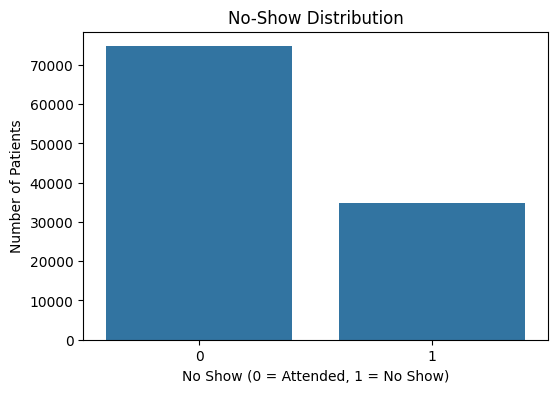

In [88]:
# Plot no-show distribution
plt.figure(figsize=(6, 4))

sns.countplot(x='no_show', data=df)

plt.title("No-Show Distribution")
plt.xlabel("No Show (0 = Attended, 1 = No Show)")
plt.ylabel("Number of Patients")

plt.show()

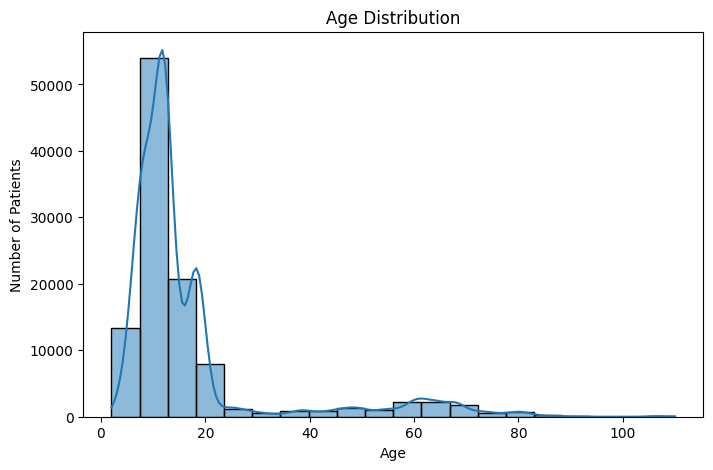

In [89]:
# Plot the distribution of patient age
plt.figure(figsize=(8, 5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

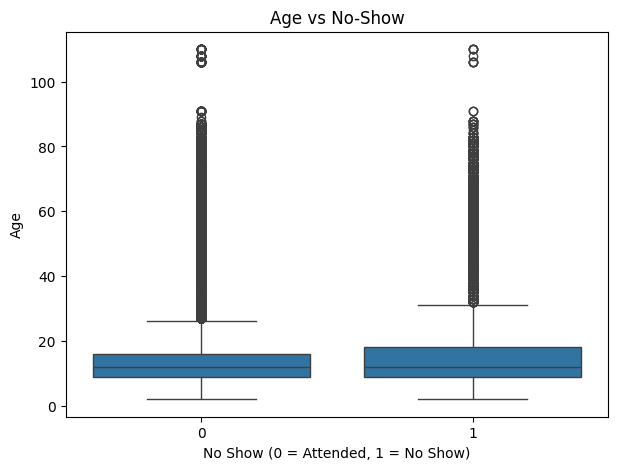

In [90]:
# Compare age between attended and no-show patients
plt.figure(figsize=(7, 5))

sns.boxplot(x='no_show', y='age', data=df)

plt.title("Age vs No-Show")
plt.xlabel("No Show (0 = Attended, 1 = No Show)")
plt.ylabel("Age")

plt.show()

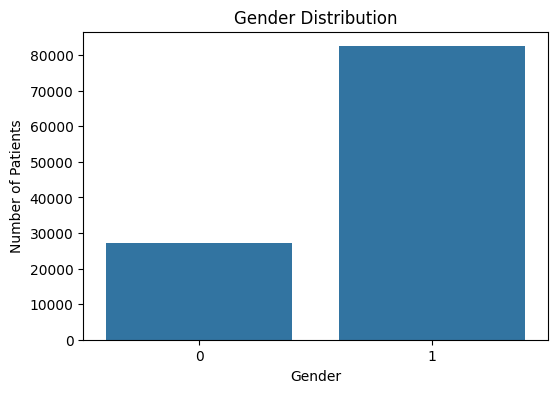

In [91]:
# Check gender distribution
plt.figure(figsize=(6, 4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

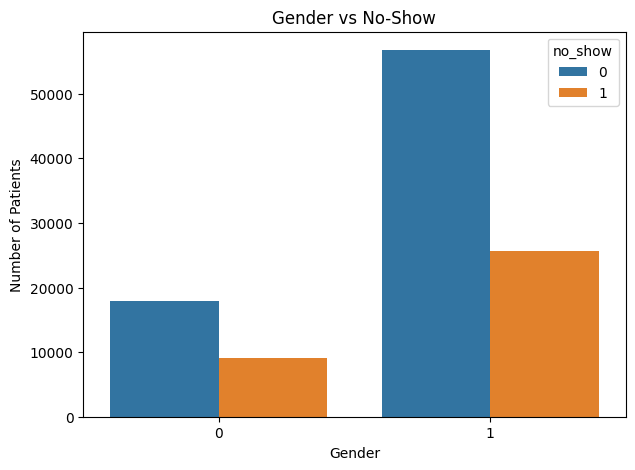

In [92]:
# Compare gender with no-show
plt.figure(figsize=(7, 5))

sns.countplot(x='gender', hue='no_show', data=df)

plt.title("Gender vs No-Show")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

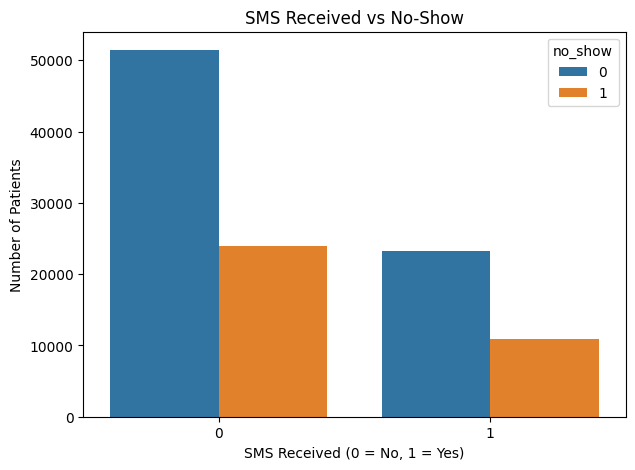

In [93]:
# Compare SMS received with no-show
plt.figure(figsize=(7, 5))

sns.countplot(x='SMS_received', hue='no_show', data=df)

plt.title("SMS Received vs No-Show")
plt.xlabel("SMS Received (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

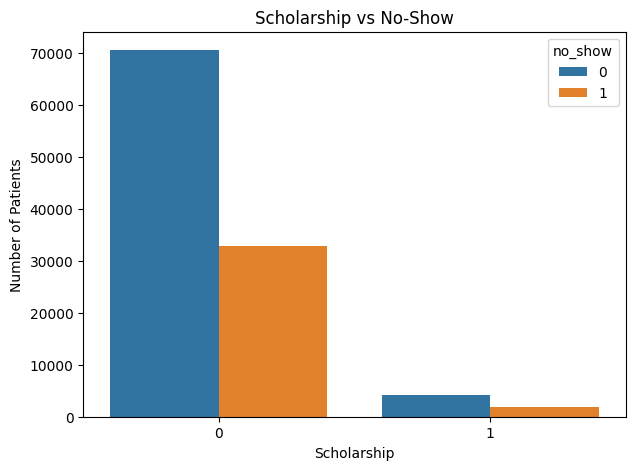

In [94]:
# Compare scholarship status with no-show
plt.figure(figsize=(7, 5))

sns.countplot(x='Scholarship', hue='no_show', data=df)

plt.title("Scholarship vs No-Show")
plt.xlabel("Scholarship")
plt.ylabel("Number of Patients")

plt.show()

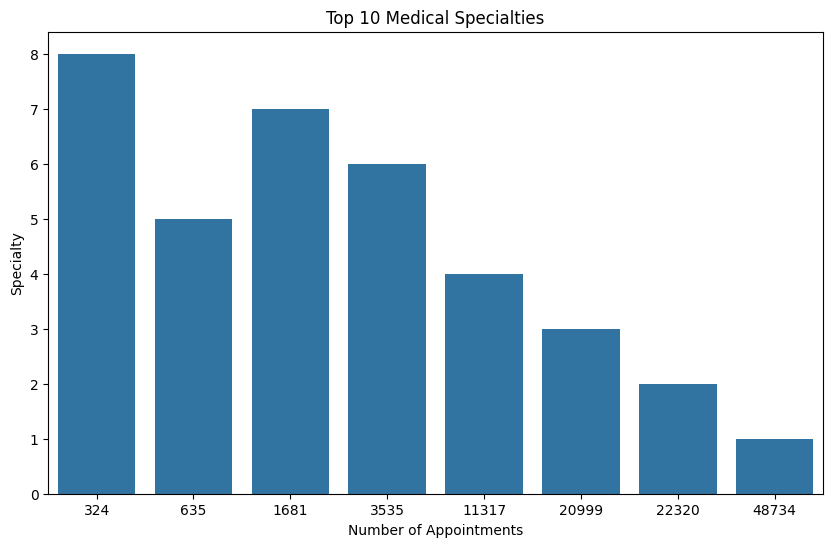

In [95]:
# Find the top 10 specialties
top_specialties = df['specialty'].value_counts().head(10)

# Plot top 10 specialties
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_specialties.values,
    y=top_specialties.index
)

plt.title("Top 10 Medical Specialties")
plt.xlabel("Number of Appointments")
plt.ylabel("Specialty")

plt.show()

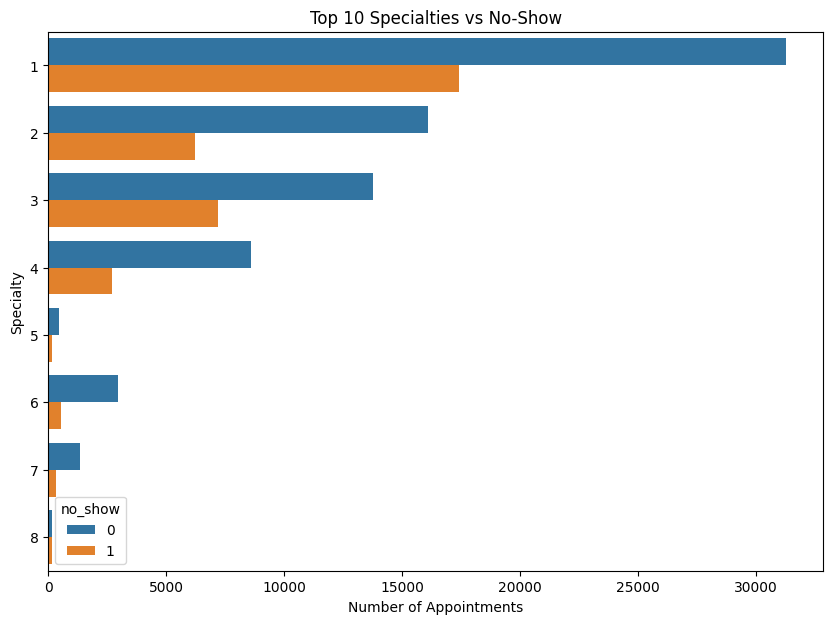

In [96]:
# Get names of top 10 specialties
top_specialty_names = df['specialty'].value_counts().head(10).index

# Filter dataset for top 10 specialties
specialty_df = df[
    df['specialty'].isin(top_specialty_names)
]

# Compare specialty with no-show
plt.figure(figsize=(10, 7))

sns.countplot(
    y='specialty',
    hue='no_show',
    data=specialty_df
)

plt.title("Top 10 Specialties vs No-Show")
plt.xlabel("Number of Appointments")
plt.ylabel("Specialty")

plt.show()

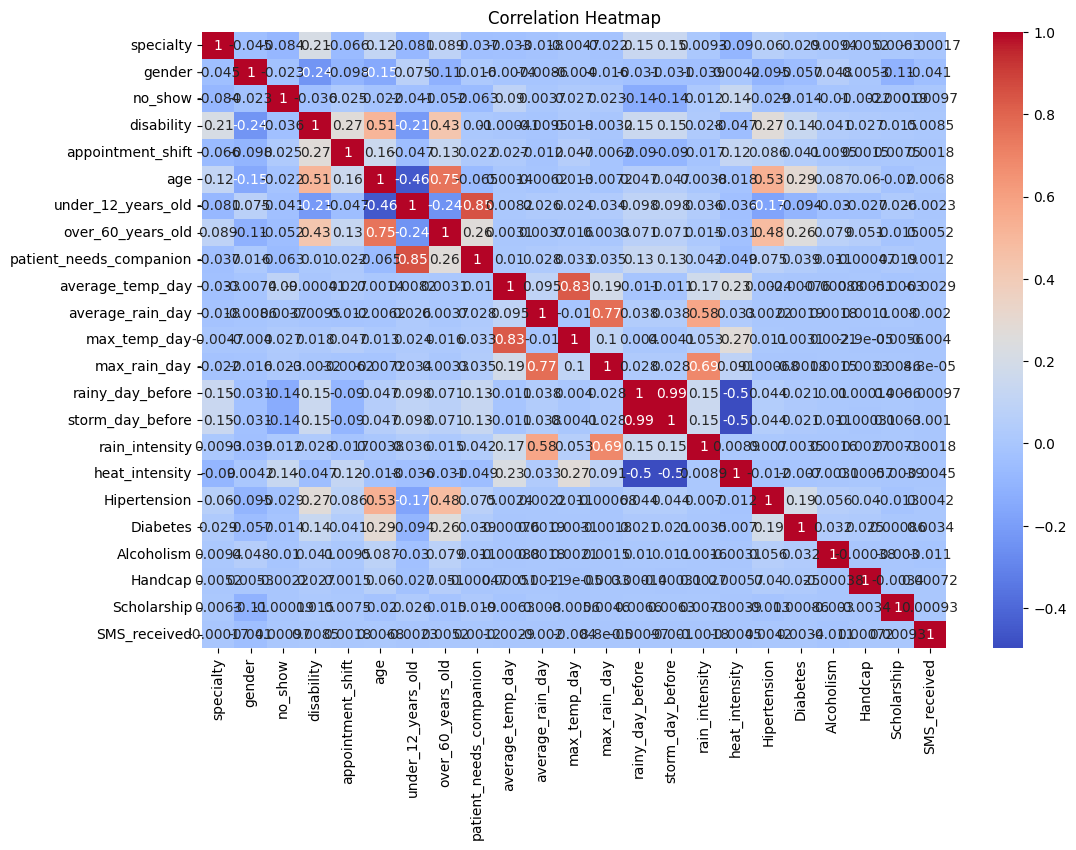

In [97]:
# Select numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlation
correlation = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# save data

In [98]:
# Check updated dataset shape
print("Dataset Shape:", df.shape)

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (109545, 24)

Data Types:
specialty                           int64
gender                              int64
no_show                             int64
disability                          int64
appointment_shift                   int64
age                                 int64
under_12_years_old                  int64
over_60_years_old                   int64
patient_needs_companion             int64
average_temp_day                  float64
average_rain_day                  float64
max_temp_day                      float64
max_rain_day                      float64
rainy_day_before                    int64
storm_day_before                    int64
rain_intensity                      int64
heat_intensity                      int64
Hipertension                        int64
Diabetes                            int64
Alcoholism                          int64
Handcap                             int64
Scholarship                         int64
SMS_received                       

In [100]:
# 1. DataFrame ko us folder ke andar save karein
df.to_csv("./clean/appointment_cleaned.csv", index=False)
print("Saved successfully!")

# 2. Ab dobara read karein (Error nahi aayega)
df_saved = pd.read_csv("./clean/appointment_cleaned.csv")
print(df_saved.shape)
df_saved.head()

Saved successfully!
(109545, 24)


,specialty,gender,no_show,disability,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,...,storm_day_before,rain_intensity,heat_intensity,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,appointment_datetime
0,1,0,1,0,1,9,1,0,1,23.18,...,1,1,3,0,0,0,0,0,0,2020-01-01 17:00:00
1,1,1,0,0,2,11,1,0,1,14.31,...,1,1,2,0,0,0,0,0,0,2020-01-01 07:00:00
2,2,1,0,0,1,8,1,0,1,21.61,...,1,1,3,0,0,0,0,0,0,2020-01-01 16:00:00
3,2,1,1,0,1,9,1,0,1,21.39,...,1,2,1,0,0,0,0,0,1,2020-01-01 14:00:00
4,3,1,0,1,2,12,0,0,0,20.15,...,1,1,1,0,0,0,0,0,0,2020-01-01 08:00:00
